
🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  
  FOUR-LA SUBSET ACTIVE — Newham, Tower Hamlets, Islington, Hounslow only (4 LAs)
  Set USE_FOUR_LA_SUBSET = False for all London or full UK.
🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  🗺️  

Loaded 19,618 rows from ../data/individuals/o_indresp.pkl


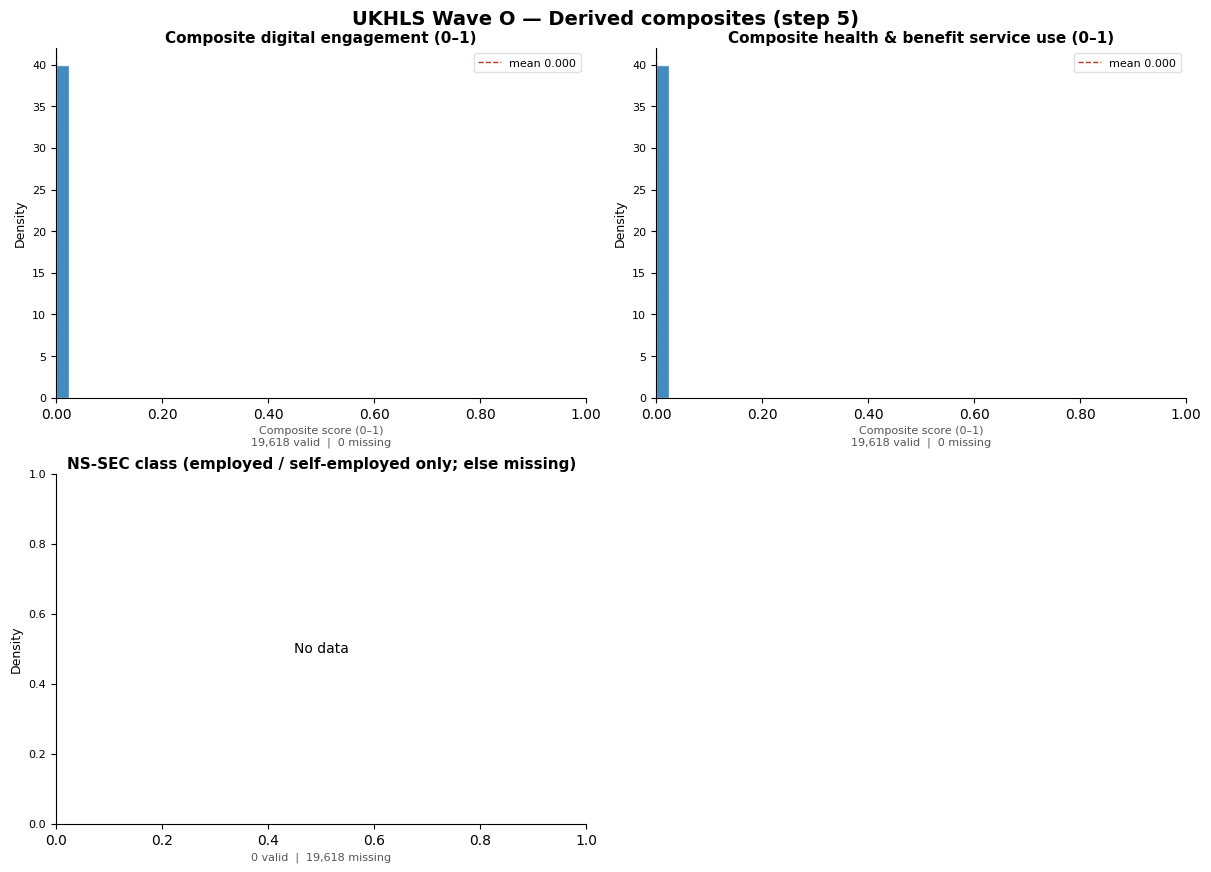

Saved ./5c_derived_visualisation.png


In [1]:
# 5b_visualise_derived_variables.ipynb
#
# Histograms for derived step-5 columns (digital_use, service_use, derived_work_status).
# Prefers o_indresp_derived.pkl from KEEP/5a; if missing, loads step-4 feature eng and computes
# composites here (same logic as KEEP/5a_derive_variables.ipynb). Output: ./5c_derived_visualisation.png

import sys, os
sys.path.insert(0, os.path.abspath('..'))

import importlib
import data_pipeline.config_variables as _cv
importlib.reload(_cv)
from data_pipeline.config_variables import DATA_FOLDER
WAVE = _cv.WAVE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from data_pipeline.config_variables_derived import DERIVED_ORDER, VARIABLE_MAP
from data_pipeline.helpers.derive_variables import (
    compute_digital_use,
    compute_service_use,
    compute_derived_work_status,
)

DERIVED_PKL = f"../{DATA_FOLDER}/4_feature_eng/{WAVE}_feature_eng.pkl"
FEATURE_PKL = f"../{DATA_FOLDER}/4_feature_eng/{WAVE}_feature_eng.pkl"
BACKFILL_PKL = f"../{DATA_FOLDER}/3_backfill_ukhls_waves/{WAVE}_indresp_backfilled.pkl"
OUT_PNG = "./5c_derived_visualisation.png"

DERIVED_COLOR = "#1f77b4"

if os.path.exists(DERIVED_PKL):
    df = pd.read_pickle(DERIVED_PKL)
    print(f"Loaded {len(df):,} rows from {DERIVED_PKL}")
elif os.path.exists(FEATURE_PKL):
    df = pd.read_pickle(FEATURE_PKL)
    print(f"No derived pickle — using {FEATURE_PKL} and computing composites (same as KEEP/5a).")
    if os.path.exists(BACKFILL_PKL):
        jb = pd.read_pickle(BACKFILL_PKL)[["pidp", f"{WAVE}_jbstat"]].rename(
            columns={f"{WAVE}_jbstat": f"{WAVE}_jbstat_raw"}
        )
        df = df.merge(jb, on="pidp", how="left")
    df[f"{WAVE}_digital_use"] = compute_digital_use(df, wave=WAVE)
    df[f"{WAVE}_service_use"] = compute_service_use(df, wave=WAVE)
    df[f"{WAVE}_derived_work_status"] = compute_derived_work_status(df, wave=WAVE)
    drop_raw = f"{WAVE}_jbstat_raw"
    if drop_raw in df.columns:
        df.drop(columns=[drop_raw], inplace=True)
else:
    raise FileNotFoundError(
        f"Neither {DERIVED_PKL} nor {FEATURE_PKL} found. "
        f"Run 4a_feature_eng_ukhls.ipynb (and optionally KEEP/5a_derive_variables.ipynb)."
    )

plot_specs = []
for base_code in DERIVED_ORDER:
    col = f"{WAVE}_{base_code}"
    if col not in df.columns:
        print(f"  WARNING: {col} missing — skipping")
        continue
    plot_specs.append(
        dict(
            base_code=base_code,
            col=col,
            label=VARIABLE_MAP.get(base_code, base_code),
        )
    )

if not plot_specs:
    raise ValueError("No derived columns found in pickle.")

n_plots = len(plot_specs)
n_cols = min(2, n_plots)
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(6 * n_cols, 4.2 * n_rows), constrained_layout=True
)
axes_flat = np.atleast_1d(axes).ravel()

for idx, spec in enumerate(plot_specs):
    ax = axes_flat[idx]
    col = spec["col"]
    data = df[col]
    n_valid = int(data.notna().sum())
    n_missing = int(data.isna().sum())
    subtitle = f"{n_valid:,} valid  |  {n_missing:,} missing"

    vals = pd.to_numeric(data, errors="coerce").dropna()
    if len(vals) == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_ylabel("Density", fontsize=9)
        x_footer = subtitle
    elif spec["base_code"] == "derived_work_status":
        bins = np.arange(-0.5, 9.5, 1.0)
        ax.hist(vals, bins=bins, color=DERIVED_COLOR, edgecolor="white", density=True, alpha=0.85)
        ax.axvline(vals.mean(), color="#c0392b", linestyle="--", linewidth=1,
                   label=f"mean {vals.mean():.3f}")
        ax.set_xlim(-0.5, 8.5)
        ax.set_ylabel("Density", fontsize=9)
        ax.legend(fontsize=8, framealpha=0.6)
        ax.set_xticks(np.arange(0, 9))
        x_footer = f"NS-SEC code (0–8)\n{subtitle}"
    else:
        bins = np.linspace(0.0, 1.0, 41)
        ax.hist(vals, bins=bins, color=DERIVED_COLOR, edgecolor="white", density=True, alpha=0.85)
        ax.axvline(vals.mean(), color="#c0392b", linestyle="--", linewidth=1,
                   label=f"mean {vals.mean():.3f}")
        ax.set_xlim(0, 1)
        ax.set_ylabel("Density", fontsize=9)
        ax.legend(fontsize=8, framealpha=0.6)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2f}"))
        x_footer = f"Composite score (0–1)\n{subtitle}"

    ax.set_title(spec["label"], fontsize=11, fontweight="bold", pad=4)
    ax.set_xlabel(x_footer, fontsize=8, labelpad=3, color="#555")
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

for unused in axes_flat[n_plots:]:
    unused.set_visible(False)

fig.suptitle(
    f"UKHLS Wave {WAVE.upper()} — Derived composites (KEEP/5a)",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
os.makedirs(os.path.dirname(OUT_PNG), exist_ok=True)
plt.savefig(OUT_PNG, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {OUT_PNG}")
